# Robomimic Dataset Inspector

This notebook helps inspect the structure and contents of robomimic HDF5 datasets.
It extracts observation structures, sample images, and key dataset information.

In [2]:
%cd /project/dl2025s/velikanm/robomimic/

/project/dl2025s/velikanm/robomimic


In [3]:
import os
import h5py
import numpy as np
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

## Configuration
Set the path to your HDF5 dataset file:

In [4]:
# Configure your dataset path here
DATASET_PATH = "datasets/demo.hdf5"  # Change this to your dataset path
#DATASET_PATH = "datasets/lift/ph/low_dim_v15.hdf5"  # Change this to your dataset path
OUTPUT_DIR = "extracted_examples"

# Create output directory
Path(OUTPUT_DIR).mkdir(exist_ok=True)

print(f"Dataset: {DATASET_PATH}")
print(f"Output: {OUTPUT_DIR}")
print(f"File exists: {os.path.exists(DATASET_PATH)}")

Dataset: datasets/demo.hdf5
Output: extracted_examples
File exists: True


## Open Dataset
Open the HDF5 file and check basic structure:

In [5]:
# Open HDF5 file
f = h5py.File(DATASET_PATH, "r", swmr=True)

print("Root keys:", list(f.keys()))

Root keys: ['data', 'mask']


## Dataset Summary

In [6]:
# Basic dataset info
if "data" in f:
    episodes = list(f["data"].keys())
    print(f"Total episodes: {len(episodes)}")
    
    # Episode lengths
    episode_lengths = []
    for ep in episodes[:5]:  # Check first 5
        if "actions" in f[f"data/{ep}"]:
            episode_lengths.append(f[f"data/{ep}/actions"].shape[0])
    
    if episode_lengths:
        print(f"Episode lengths (first 5): {episode_lengths}")
        print(f"Average length: {np.mean(episode_lengths):.1f}")
else:
    print("No 'data' group found")

Total episodes: 200
Episode lengths (first 5): [66, 57, 54, 63, 64]
Average length: 60.8


In [7]:
# Environment metadata
if "data" in f and hasattr(f["data"], 'attrs') and "env_args" in f["data"].attrs:
    try:
        env_meta = json.loads(f["data"].attrs["env_args"])
        print("Environment metadata:")
        for key, value in env_meta.items():
            if isinstance(value, dict) and len(str(value)) > 100:
                print(f"  {key}: <complex dict with {len(value)} keys>")
            else:
                print(f"  {key}: {value}")
    except Exception as e:
        print(f"Could not parse environment metadata: {e}")
else:
    print("No environment metadata found")

Environment metadata:
  type: 3
  env_name: RealPandaEnv
  env_kwargs: <complex dict with 4 keys>


In [8]:
# Filter keys (train/val splits etc.)
if "mask" in f:
    filter_keys = list(f["mask"].keys())
    print("Filter keys available:")
    for fk in filter_keys:
        count = len(f[f"mask/{fk}"])
        print(f"  {fk}: {count} episodes")
else:
    print("No filter keys found")

Filter keys available:
  train: 180 episodes
  valid: 20 episodes


## Observation Structure
Analyze the observation fields in the first episode:

In [9]:
# Get first episode
if "data" in f:
    episodes = list(f["data"].keys())
    if episodes:
        episode_name = episodes[0]
        print(f"Analyzing episode: {episode_name}")
        
        episode_group = f[f"data/{episode_name}"]
        print(f"Episode keys: {list(episode_group.keys())}")
    else:
        print("No episodes found")
        episode_name = None
else:
    print("No data group found")
    episode_name = None

Analyzing episode: demo_0
Episode keys: ['actions', 'dones', 'interventions', 'next_obs', 'obs', 'policy_acting', 'rewards', 'states', 'user_acting']


In [10]:
if episode_name:
    episode_group = f[f"data/{episode_name}"]
    
    # Observation structure
    if "obs" in episode_group:
        obs_group = episode_group["obs"]
        print(f"\nObservation keys ({len(obs_group.keys())} total):")
        print(f"{'Key':<25} | {'Shape':<20} | {'Type':<10} | {'Category'}")
        print("-" * 70)
        
        for obs_key in sorted(obs_group.keys()):
            obs_dataset = obs_group[obs_key]
            shape = obs_dataset.shape
            dtype = obs_dataset.dtype
            
            # Determine observation type
            obs_type = "unknown"
            if len(shape) >= 3 and shape[-1] in [1, 3, 4]:
                if len(shape) == 4:  # (T, H, W, C)
                    obs_type = "image_sequence"
                elif len(shape) == 3:  # (H, W, C)
                    obs_type = "image"
            elif len(shape) == 2:  # (T, N) - time series of vectors
                obs_type = "vector_sequence"
            elif len(shape) == 1:  # (N,) - single vector
                obs_type = "vector"
            
            print(f"{obs_key:<25} | {str(shape):<20} | {str(dtype):<10} | {obs_type}")
    else:
        print("No 'obs' group found in episode")


Observation keys (7 total):
Key                       | Shape                | Type       | Category
----------------------------------------------------------------------
dq                        | (66, 7)              | float64    | vector_sequence
ee_pose                   | (66, 7)              | float64    | vector_sequence
ee_vel                    | (66, 6)              | float64    | vector_sequence
gripper_position          | (66, 1)              | float64    | vector_sequence
image                     | (66, 120, 120, 3)    | uint8      | image_sequence
image_wrist               | (66, 120, 120, 3)    | uint8      | image_sequence
q                         | (66, 7)              | float64    | vector_sequence


In [11]:
if episode_name:
    episode_group = f[f"data/{episode_name}"]
    
    # Other data keys
    other_keys = [k for k in episode_group.keys() if k not in ['obs', 'next_obs']]
    if other_keys:
        print("\nOther data keys:")
        print(f"{'Key':<25} | {'Shape':<20} | {'Type':<10}")
        print("-" * 50)
        for key in other_keys:
            if isinstance(episode_group[key], h5py.Dataset):
                shape = episode_group[key].shape
                dtype = episode_group[key].dtype
                print(f"{key:<25} | {str(shape):<20} | {str(dtype):<10}")
    
    # Next observations
    if "next_obs" in episode_group:
        print(f"\nNext observation keys: {len(episode_group['next_obs'].keys())} available")


Other data keys:
Key                       | Shape                | Type      
--------------------------------------------------
actions                   | (66, 7)              | float64   
dones                     | (66,)                | int64     
interventions             | (66, 1)              | bool      
policy_acting             | (67,)                | bool      
rewards                   | (66,)                | float64   
states                    | (0,)                 | float64   
user_acting               | (67, 1)              | bool      

Next observation keys: 7 available


## Sample Data
Extract and display sample observations and actions:

In [12]:
## Plan
# .load_episode(idx)
# .load_frame(idx)

# f
# * data
# ** demo_0
# *** actions
# *** obs
# **** image (66, 120, 120, 3) (T, H, W, C)

[-0.0674089   0.1127682   0.16130417 -0.25474834  0.1000312  -0.02599903
 -1.        ]


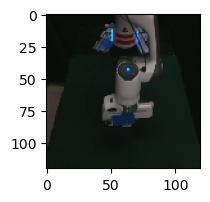

In [13]:
import torch.utils.data as data  # dataset shuffling, sample batching, ...
from torchvision import transforms

DEBUG = False
debug_points = {}
def debug(point: str, message: str):
    if DEBUG:
        if not point in debug_points:
            debug_points[point] = True
            print(f"{point}: {message}")

def display_train_image(image):
    plt.figure(figsize=(2, 2))
    plt.imshow(image)

def imginfo(img):
    print(f"shape={img.shape} dtype={img.dtype} min={img.min():.4f} max={img.max():.4f}")

class RobomimicLoader(data.Dataset):
    def __init__(self, dataset_path):
        self.f = h5py.File(dataset_path, "r", swmr=True)
        
        # calculate dataset length
        length = 0
        episodes = list(self.f["data"].keys())
        debug("robomimic_init", f"len(episodes)={len(episodes)}")
        for episode_name in episodes:
            episodes_group = self.f[f"data/{episode_name}"]
            length += len(episodes_group["obs/image"])
        self.length = length

    def load_episode(self, idx: int):
        """
        Arguments:
            idx: int 

        Returns:
            out torch.tensor (B, T, output_size),
            latent torch.tensor (B, latent_size),
            outcome torch.tensor (B, 1)
        """
        episodes = list(self.f["data"].keys())
        debug("load_episode", f"len(episodes) = {len(episodes)}")
        
        episode_name = episodes[idx % len(episodes)]
        debug("load_episode_name", f"Analyzing episode: {episode_name}")

        episode_group = self.f[f"data/{episode_name}"]
        debug("load_episode_keys", f"Episode keys: {list(episode_group.keys())}")
        
        debug("load_episode_type", type(episode_group))
        return episode_group
    
    def load_frame(self, episode_group, idx: int):
        """
        action: (7)
        image: (H, W, C)
        """
        n = len(episode_group["actions"])
        return (
            episode_group["actions"][idx % n],
            episode_group["obs/image"][idx % n]
        )
    
    def __getitem__(self, idx: int):
        """
        Arguments:
            idx: int 

        Returns:
            image: (C, H, W)
            action: (D)
        """
        episode = self.load_episode(idx)
        action, image = self.load_frame(episode, idx)
        
        # fix image shape - must be (h, w, RGB)
        if len(image.shape) == 2: # (h, w)
            image = image[:, :, np.newaxis]
        if image.shape[2] == 1:
            image = np.tile(image, 3)
        elif image.shape[2] > 3:
            image = image[:, :, :3]


        train_transform = transforms.Compose([
            transforms.ToTensor(), # from numpy to torch tensor
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),

            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])


        val_transform = transforms.Compose([
            transforms.ToTensor(), # from numpy to torch tensor
            transforms.Resize((224, 224)),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        image = train_transform(image)
        
        return (image, action)
        
    def __len__(self):
        return self.length

loader = RobomimicLoader(DATASET_PATH)
episode = loader.load_episode(0)
action, image = loader.load_frame(episode, 60)

print(action)
display_train_image(image)

In [14]:
image, action = loader[0]
imginfo(image)
imginfo(action)
print(len(loader))

shape=torch.Size([3, 224, 224]) dtype=torch.float32 min=-2.1179 max=2.1098
shape=(7,) dtype=float64 min=-0.2647 max=1.0000
11524


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[-0.0674089   0.1127682   0.16130417 -0.25474834  0.1000312  -0.02599903
 -1.        ]


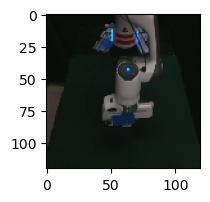

In [17]:
%load_ext autoreload
%autoreload 2

from my_datasest import RobomimicLoader as MyLoader
loader = MyLoader(DATASET_PATH)

episode = loader.load_episode(0)
action, image = loader.load_frame(episode, 60)

print(action)
display_train_image(image)


In [18]:
image, action = loader[0]
imginfo(image)
imginfo(action)

print(len(loader))

shape=torch.Size([3, 224, 224]) dtype=torch.float32 min=-2.1179 max=1.6956
shape=(7,) dtype=float64 min=-0.2647 max=1.0000
11524


Sample observations at timestep 0:

dq: [ 4.75601098e-04  3.05458129e-04 -6.90942813e-04 -1.06380096e-03
  6.08598344e-06 -1.28591879e-03  2.04698682e-03]

ee_pose: [ 4.33203007e-01 -2.75064078e-04  2.91211708e-01 -9.98982966e-01
  4.32599224e-02 -1.26796598e-02  9.45801730e-04]

ee_vel: [-6.71710835e-04 -6.82195664e-05 -7.33379527e-04  2.72278229e-04
  2.65684031e-03 -2.23019041e-03]

gripper_position: [0.080526]

image: image data (120, 120, 3) - displaying...

image_wrist: image data (120, 120, 3) - displaying...

q: [ 2.03901765e-04 -3.13364456e-01 -1.08981247e-03 -2.51462694e+00
  6.03813968e-04  2.22667719e+00  8.70757514e-01]


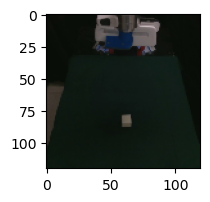

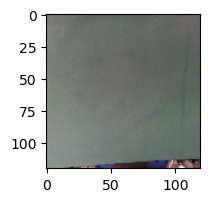

In [14]:
if episode_name:
    episode_group = f[f"data/{episode_name}"]
    timestep = 0  # Look at first timestep
    
    print(f"Sample observations at timestep {timestep}:")
    
    if "obs" in episode_group:
        obs_group = episode_group["obs"]
        
        for obs_key in sorted(obs_group.keys()):
            obs_dataset = obs_group[obs_key]
            
            try:
                # Get data for timestep
                if len(obs_dataset.shape) > 0 and timestep < obs_dataset.shape[0]:
                    obs_data = obs_dataset[timestep]
                else:
                    obs_data = obs_dataset[()]
                
                # Display based on type
                if len(obs_dataset.shape) >= 3 and obs_dataset.shape[-1] in [1, 3]:
                    print(f"\n{obs_key}: image data {obs_data.shape} - displaying...")
                    display_train_image(obs_data)
                else:
                    if isinstance(obs_data, np.ndarray):
                        if obs_data.size <= 20:
                            print(f"\n{obs_key}: {obs_data}")
                        else:
                            print(f"\n{obs_key}: shape={obs_data.shape}, min={np.min(obs_data):.3f}, max={np.max(obs_data):.3f}, mean={np.mean(obs_data):.3f}")
                            print(f"  first 10 values: {obs_data.flatten()[:10]}")
                    else:
                        print(f"\n{obs_key}: {obs_data}")
                        
            except Exception as e:
                print(f"\n{obs_key}: Error reading data - {e}")

In [41]:
if episode_name:
    episode_group = f[f"data/{episode_name}"]
    
    if "actions" in episode_group:
        actions = episode_group["actions"]
        print(f"Actions shape: {actions.shape}, dtype: {actions.dtype}")
        
        # Show first few timesteps
        num_show = min(5, actions.shape[0])
        print(f"\nFirst {num_show} actions:")
        for t in range(num_show):
            action = actions[t]
            print(f"  t={t}: {action}")
            
        # Action statistics
        print(f"\nAction statistics:")
        print(f"  Min: {np.min(actions[()])}")
        print(f"  Max: {np.max(actions[()])}")
        print(f"  Mean: {np.mean(actions[()])}")
        print(f"  Std: {np.std(actions[()])}")
    else:
        print("No actions found")

Actions shape: (66, 7), dtype: float64

First 5 actions:
  t=0: [-0.01728681 -0.01287809  0.02150786  0.03470355 -0.08398321 -0.26471839
  1.        ]
  t=1: [-0.02903676 -0.03145326  0.04185413  0.03068078 -0.0828308  -0.27059845
  1.        ]
  t=2: [-0.045291   -0.0456926   0.05257651  0.03653023 -0.08349406 -0.27933578
  1.        ]
  t=3: [-0.05661664 -0.06039999  0.05266223  0.03644213 -0.07572851 -0.28370365
  1.        ]
  t=4: [-0.07204724 -0.06361158  0.02873762  0.03719272 -0.06726191 -0.28716479
  1.        ]

Action statistics:
  Min: -1.0
  Max: 1.0
  Mean: 0.02913168850309122
  Std: 0.40981239002110337


## Image Extraction
Extract and display sample images (if any):

In [ ]:
# Find image observations
image_keys = []

if episode_name:
    episode_group = f[f"data/{episode_name}"]
    
    if "obs" in episode_group:
        obs_group = episode_group["obs"]
        
        for obs_key in obs_group.keys():
            obs_dataset = obs_group[obs_key]
            shape = obs_dataset.shape
            
            # Check if this looks like image data
            if len(shape) >= 3 and shape[-1] in [1, 3, 4]:
                image_keys.append(obs_key)
                
print(f"Found {len(image_keys)} image observations: {image_keys}")

In [ ]:
# Extract and display images
if image_keys and episode_name:
    episode_group = f[f"data/{episode_name}"]
    obs_group = episode_group["obs"]
    
    # Show first few timesteps
    timesteps_to_show = [0, 1, 2]  # First 3 timesteps
    
    for obs_key in image_keys[:2]:  # Show first 2 image types
        print(f"\nExtracting images for: {obs_key}")
        obs_dataset = obs_group[obs_key]
        
        fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(12, 4))
        if len(timesteps_to_show) == 1:
            axes = [axes]
            
        for i, t in enumerate(timesteps_to_show):
            if t < obs_dataset.shape[0]:
                try:
                    # Get image data
                    if len(obs_dataset.shape) == 4:  # Time series
                        image_data = obs_dataset[t]
                    else:  # Single image
                        image_data = obs_dataset[()]
                    
                    # Normalize if needed
                    if image_data.dtype in [np.float32, np.float64]:
                        if image_data.max() <= 1.0:
                            image_data = (image_data * 255).astype(np.uint8)
                        else:
                            image_data = np.clip(image_data, 0, 255).astype(np.uint8)
                    
                    # Display
                    if len(image_data.shape) == 3 and image_data.shape[-1] == 1:
                        axes[i].imshow(image_data.squeeze(-1), cmap='gray')
                    else:
                        axes[i].imshow(image_data)
                    
                    axes[i].set_title(f'{obs_key} t={t}')
                    axes[i].axis('off')
                    
                except Exception as e:
                    axes[i].text(0.5, 0.5, f'Error: {e}', transform=axes[i].transAxes, ha='center')
                    axes[i].set_title(f'{obs_key} t={t} (error)')
                    
        plt.tight_layout()
        plt.show()
        
else:
    print("No image observations found or no episode data")

## Save Summary
Save the dataset information to a JSON file:

In [ ]:
# Collect dataset information
dataset_info = {
    "dataset_path": DATASET_PATH,
    "root_keys": list(f.keys())
}

# Add episode info
if "data" in f:
    episodes = list(f["data"].keys())
    dataset_info["total_episodes"] = len(episodes)
    
    # Sample episode info
    if episodes:
        sample_ep = episodes[0]
        episode_group = f[f"data/{sample_ep}"]
        
        if "obs" in episode_group:
            obs_info = {}
            for obs_key in episode_group["obs"].keys():
                obs_dataset = episode_group["obs"][obs_key]
                obs_info[obs_key] = {
                    "shape": list(obs_dataset.shape),
                    "dtype": str(obs_dataset.dtype)
                }
            dataset_info["observation_structure"] = obs_info
            
        if "actions" in episode_group:
            actions = episode_group["actions"]
            dataset_info["action_info"] = {
                "shape": list(actions.shape),
                "dtype": str(actions.dtype)
            }

# Add environment metadata
if "data" in f and hasattr(f["data"], 'attrs') and "env_args" in f["data"].attrs:
    try:
        env_meta = json.loads(f["data"].attrs["env_args"])
        dataset_info["env_metadata"] = env_meta
    except:
        pass

# Save to file
info_file = Path(OUTPUT_DIR) / "dataset_info.json"
with open(info_file, 'w') as json_file:
    json.dump(dataset_info, json_file, indent=2)

print(f"Dataset summary saved to: {info_file}")
print(f"Summary contains {len(dataset_info)} top-level keys")

## Cleanup
Close the HDF5 file:

In [ ]:
# Close HDF5 file
f.close()
print("HDF5 file closed successfully")